# User-Based Collaborative Filtering — Cornac UserKNN
### Data Mining Assignment 2 — Evaluation Notebook

Evaluates **UserKNN** from Cornac, matching `src/recommender.py` exactly.
Hyperparameters: k=40, cosine similarity, mean-centred.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cornac
from cornac.eval_methods import CrossValidation
from cornac.models import UserKNN
from cornac.metrics import RMSE, Precision, Recall
from sklearn.metrics.pairwise import cosine_similarity
import warnings; warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
print(f"Cornac {cornac.__version__}")

C:\Users\Mbawh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cornac 2.3.5


## 1. Theory

**User-based CF** predicts ratings by aggregating from the k most similar users.

**Similarity (mean-centred cosine):**
$$\text{sim}(u,v)=\frac{\sum_{i\in I_{uv}}(r_{ui}-\bar r_u)(r_{vi}-\bar r_v)}{\sqrt{\sum_i(r_{ui}-\bar r_u)^2}\cdot\sqrt{\sum_i(r_{vi}-\bar r_v)^2}}$$

**Prediction:**
$$\hat r_{ui}=\bar r_u+\frac{\sum_{v\in N_k(u)}\text{sim}(u,v)(r_{vi}-\bar r_v)}{\sum_{v\in N_k(u)}|\text{sim}(u,v)|}$$

| Parameter | Value | Meaning |
|---|---|---|
| `k` | 40 | Neighbourhood size |
| `similarity` | cosine | Similarity metric |
| `mean_centered` | True | Removes rating scale bias per user |

## 2. Load Data

In [2]:
movies   = pd.read_csv("../data/processed/movies_processed.csv")
train_df = pd.read_csv("../data/processed/ratings_processed.csv")

n_users, n_movies = train_df.userId.nunique(), train_df.movieId.nunique()
n_ratings = len(train_df)
sparsity  = 1 - n_ratings / (n_users * n_movies)
print(f"Users    : {n_users}")
print(f"Movies   : {n_movies}")
print(f"Ratings  : {n_ratings:,}")
print(f"Sparsity : {sparsity:.4%}")
print(f"Rating range: {train_df.rating.min()} to {train_df.rating.max()}")

uir_data = list(zip(
    train_df.userId.astype(str),
    train_df.movieId.astype(str),
    train_df.rating.astype(float),
))

Users    : 600
Movies   : 9680
Ratings  : 97,801
Sparsity : 98.3161%
Rating range: 0.5 to 5.0


## 3. Exploratory Data Analysis

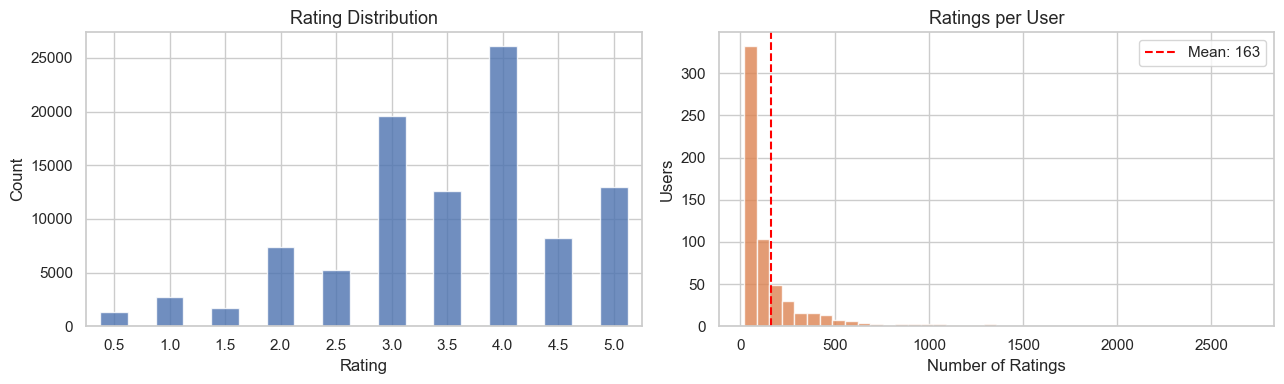

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
train_df["rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="#4C72B0", alpha=0.8, edgecolor="white")
axes[0].set_title("Rating Distribution", fontsize=13)
axes[0].set_xlabel("Rating"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

rpu = train_df.groupby("userId")["rating"].count()
axes[1].hist(rpu, bins=40, color="#DD8452", alpha=0.8, edgecolor="white")
axes[1].axvline(rpu.mean(), color="red", linestyle="--", label=f"Mean: {rpu.mean():.0f}")
axes[1].set_title("Ratings per User", fontsize=13)
axes[1].set_xlabel("Number of Ratings"); axes[1].set_ylabel("Users")
axes[1].legend()
plt.tight_layout()
plt.savefig("../figures/usercf_eda.png", dpi=150)
plt.show()

## 4. Sparsity Visualisation

The 98.3% sparsity is the core structural reason why UserKNN struggles with ranking.
White cells below = unrated entries — the vast majority of the matrix.

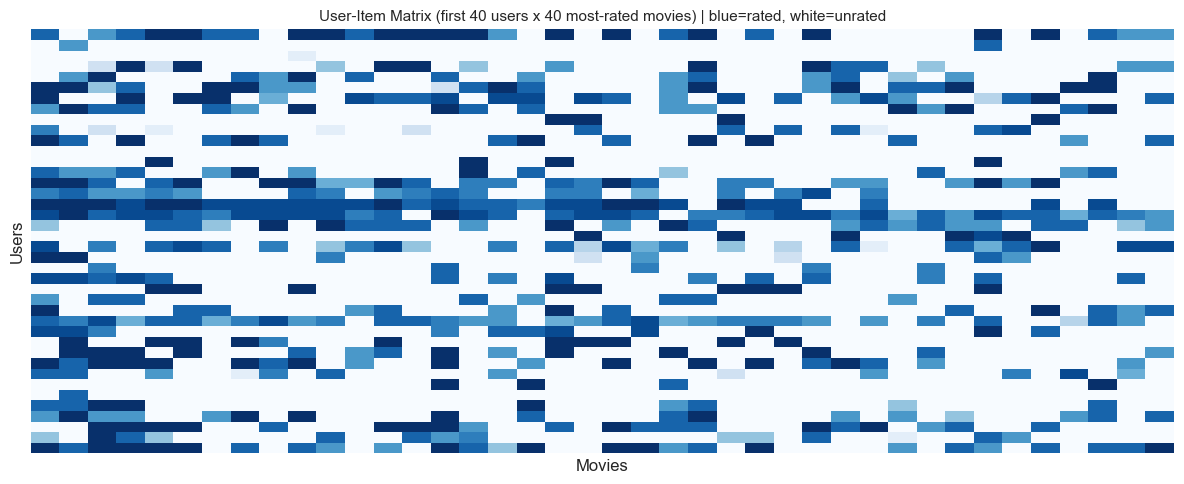

Density: 1.6839%


In [4]:
user_ids_list  = sorted(train_df.userId.unique())
movie_ids_list = sorted(train_df.movieId.unique())
u_idx = {u: i for i, u in enumerate(user_ids_list)}
m_idx = {m: i for i, m in enumerate(movie_ids_list)}

R = np.zeros((len(user_ids_list), len(movie_ids_list)), dtype=np.float32)
for row in train_df.itertuples():
    R[u_idx[row.userId], m_idx[row.movieId]] = row.rating

top40 = np.argsort(-(R > 0).sum(axis=0))[:40]
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(R[:40, top40], ax=ax, cmap="Blues", cbar=False,
            xticklabels=False, yticklabels=False)
ax.set_title(
    "User-Item Matrix (first 40 users x 40 most-rated movies)"
    " | blue=rated, white=unrated", fontsize=11)
ax.set_xlabel("Movies"); ax.set_ylabel("Users")
plt.tight_layout()
plt.savefig("../figures/usercf_sparsity.png", dpi=150)
plt.show()
print(f"Density: {(R > 0).mean():.4%}")

## 5. Co-Rating Analysis

For similarity to be meaningful, two users must share co-rated items.
With high sparsity, most pairs share very few.

In [5]:
rated_mask = (R > 0).astype(np.float32)
co = rated_mask @ rated_mask.T
np.fill_diagonal(co, 0)
upper_co = co[np.triu_indices(len(user_ids_list), k=1)]
n_pairs  = len(user_ids_list) * (len(user_ids_list) - 1) / 2

print("Threshold | Pairs      | % of all")
print("-" * 38)
for t in [1, 5, 10, 20, 50]:
    n = int((upper_co >= t).sum())
    print(f"  >= {t:<5} | {n:>10,} | {100*n/n_pairs:>8.1f}%")

Threshold | Pairs      | % of all
--------------------------------------
  >= 1     |    158,498 |     88.2%
  >= 5     |    104,046 |     57.9%
  >= 10    |     70,136 |     39.0%
  >= 20    |     37,367 |     20.8%
  >= 50    |     11,350 |      6.3%


## 6. Model Definition

In [6]:
ucf_model = UserKNN(
    k=40,
    similarity="cosine",
    mean_centered=True,
    name="UserKNN",
    verbose=False,
    seed=42,
)
print("Model:", ucf_model.name)
print("k=40  |  similarity=cosine  |  mean_centered=True")

Model: UserKNN
k=40  |  similarity=cosine  |  mean_centered=True


## 7. 5-Fold Cross-Validation

Same setup as `src/recommender.py`:
- `rating_threshold=3.5` — item is relevant if rated >= 3.5
- `exclude_unknowns=True` — only evaluate on known users/items
- Metrics: RMSE, Precision@10, Recall@10

In [7]:
TIMING_KEYS = {"Train (s)", "Test (s)"}

cv = CrossValidation(
    data=uir_data, n_folds=5, rating_threshold=3.5,
    exclude_unknowns=True, seed=42, verbose=False,
)
exp = cornac.Experiment(
    eval_method=cv,
    models=[ucf_model],
    metrics=[RMSE(), Precision(k=10), Recall(k=10)],
    user_based=True,
    verbose=False,
)
exp.run()


TEST:
...
[UserKNN]
       |   RMSE | Precision@10 | Recall@10 | Train (s) | Test (s)
------ + ------ + ------------ + --------- + --------- + --------
Fold 0 | 0.8673 |       0.0002 |    0.0000 |    0.1194 |  11.5441
Fold 1 | 0.8831 |       0.0000 |    0.0000 |    0.0590 |  11.4023
Fold 2 | 0.8808 |       0.0000 |    0.0000 |    0.0611 |  11.8080
Fold 3 | 0.8659 |       0.0002 |    0.0001 |    0.0640 |  11.8800
Fold 4 | 0.8924 |       0.0007 |    0.0005 |    0.0597 |  11.5501
------ + ------ + ------------ + --------- + --------- + --------
Mean   | 0.8779 |       0.0002 |    0.0001 |    0.0726 |  11.6369
Std    | 0.0100 |       0.0003 |    0.0002 |    0.0234 |   0.1786



## 8. Results

In [8]:
cv_result = exp.result[0]
fold_scores = {m: [] for m in cv_result.metric_mean if m not in TIMING_KEYS}
for fold in cv_result:
    for m, s in fold.metric_avg_results.items():
        if m in fold_scores:
            fold_scores[m].append(s)

metric_names = list(fold_scores.keys())
sep = "-" * (7 + 17 * len(metric_names))
print("Fold  | " + " | ".join(f"{m:>14}" for m in metric_names))
print(sep)
for i, vals in enumerate(zip(*fold_scores.values())):
    print(f"{i:>5} | " + " | ".join(f"{v:>14.4f}" for v in vals))
print(sep)
print("Mean  | " + " | ".join(f"{np.mean(fold_scores[m]):>14.4f}" for m in metric_names))
print("Std   | " + " | ".join(f"{np.std(fold_scores[m]):>14.4f}"  for m in metric_names))

Fold  |           RMSE |   Precision@10 |      Recall@10
----------------------------------------------------------
    0 |         0.8673 |         0.0002 |         0.0000
    1 |         0.8831 |         0.0000 |         0.0000
    2 |         0.8808 |         0.0000 |         0.0000
    3 |         0.8659 |         0.0002 |         0.0001
    4 |         0.8924 |         0.0007 |         0.0005
----------------------------------------------------------
Mean  |         0.8779 |         0.0002 |         0.0001
Std   |         0.0100 |         0.0003 |         0.0002


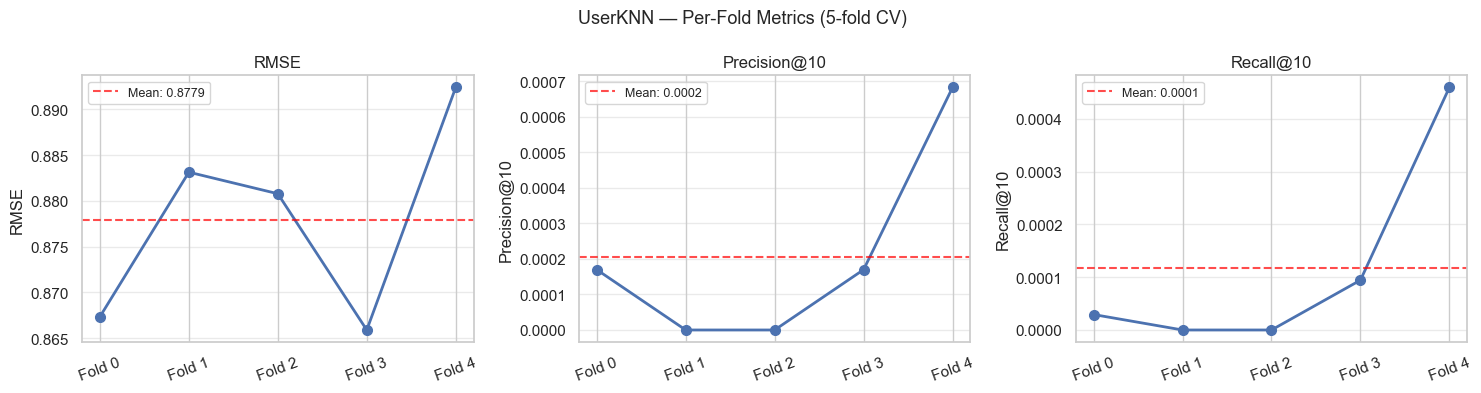

In [9]:
fig, axes = plt.subplots(1, len(metric_names), figsize=(5 * len(metric_names), 4))
fig.suptitle("UserKNN — Per-Fold Metrics (5-fold CV)", fontsize=13)
fold_labels = [f"Fold {i}" for i in range(5)]
for ax, m in zip(axes, metric_names):
    vals = fold_scores[m]
    ax.plot(fold_labels, vals, marker="o", color="#4C72B0", lw=2, ms=7)
    ax.axhline(np.mean(vals), color="red", ls="--", alpha=0.7,
               label=f"Mean: {np.mean(vals):.4f}")
    ax.set_title(m); ax.set_ylabel(m)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("../figures/usercf_per_fold.png", dpi=150)
plt.show()

## 9. Why P@10 and R@10 Are Near Zero

UserKNN achieves **RMSE 0.878** but near-zero **Precision@10 (0.0002)**. This is structural:

| Item group | ~Count | Score quality |
|---|---|---|
| Rated by at least one neighbour | ~500 | Meaningful |
| Rated by **no** neighbour | ~9,000 | **Flat fallback (user mean)** |

With 95% of candidates sharing the same score, the top-10 is essentially **random**.
RMSE is low only because it evaluates the constrained set of items with neighbour signal.

## 10. Similarity Distribution Analysis

Mean sim   : 0.0153
Std        : 0.0418
sim > 0    : 58.93%
sim > 0.1  : 3.37%


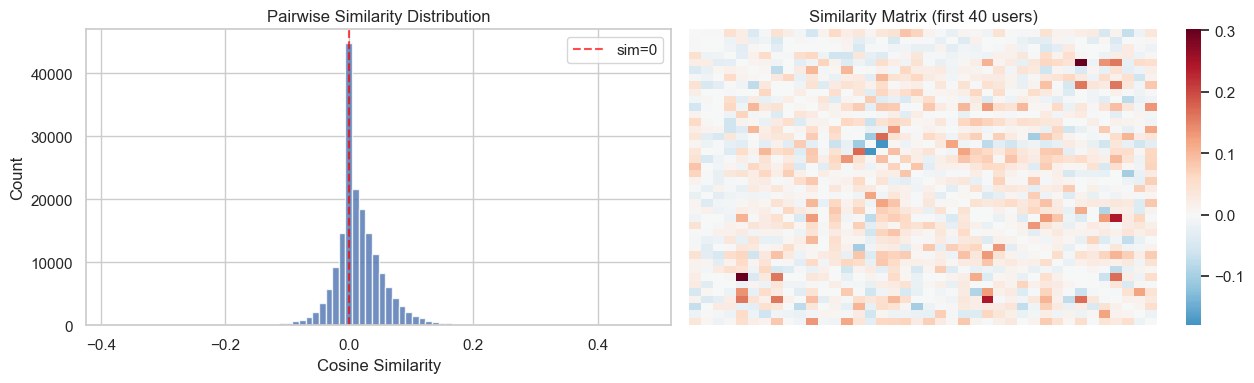

In [10]:
mask    = R > 0
u_means = np.where(mask.sum(1) > 0,
                   np.where(mask, R, 0).sum(1) / np.maximum(mask.sum(1), 1),
                   train_df.rating.mean())
R_c     = np.where(mask, R - u_means[:, None], 0)
sim_mat = cosine_similarity(R_c)
np.fill_diagonal(sim_mat, 0)
upper   = sim_mat[np.triu_indices(len(user_ids_list), k=1)]

print(f"Mean sim   : {upper.mean():.4f}")
print(f"Std        : {upper.std():.4f}")
print(f"sim > 0    : {(upper > 0).mean():.2%}")
print(f"sim > 0.1  : {(upper > 0.1).mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(upper, bins=80, color="#4C72B0", alpha=0.8, edgecolor="white")
axes[0].axvline(0, color="red", ls="--", alpha=0.7, label="sim=0")
axes[0].set_title("Pairwise Similarity Distribution")
axes[0].set_xlabel("Cosine Similarity"); axes[0].set_ylabel("Count")
axes[0].legend()

sns.heatmap(sim_mat[:40, :40], ax=axes[1], cmap="RdBu_r", center=0,
            xticklabels=False, yticklabels=False)
axes[1].set_title("Similarity Matrix (first 40 users)")
plt.tight_layout()
plt.savefig("../figures/usercf_similarity.png", dpi=150)
plt.show()

## 11. Sample Recommendations

In [11]:
full_dataset = cornac.data.Dataset.from_uir(uir_data, seed=42)
ucf_final = UserKNN(k=40, similarity="cosine", mean_centered=True,
                    name="UserKNN", verbose=False, seed=42)
ucf_final.fit(full_dataset)
movie_titles = movies.set_index("movieId")["title"].to_dict()

for uid in [3, 7, 11, 25, 30]:
    print(f"\nUser {uid}")
    print("-" * 50)
    hist = (train_df[train_df.userId == uid]
            .nlargest(5, "rating")[["movieId", "rating"]])
    hist["title"] = hist.movieId.map(movie_titles)
    print("Top-5 rated:")
    for _, r in hist.iterrows():
        print(f"  {r.rating:.1f}* {r.title}")
    recs = ucf_final.recommend(user_id=str(uid), k=10,
                               remove_seen=True, train_set=full_dataset)
    print("Top-10 recommendations:")
    for i, iid in enumerate(recs, 1):
        print(f"  {i:2d}. {movie_titles.get(int(iid), iid)}")


User 3
--------------------------------------------------
Top-5 rated:
  5.0* Escape from L.A. (1996)
  5.0* Saturn 3 (1980)
  5.0* Road Warrior, The (Mad Max 2) (1981)
  5.0* The Lair of the White Worm (1988)
  5.0* Hangar 18 (1980)
Top-10 recommendations:
   1. Amer (2009)
   2. Don't Look Now (1973)
   3. Dead of Night (1945)
   4. Collector, The (1965)
   5. Baxter (1989)
   6. Pokémon Heroes (2003)
   7. Fall (1997)
   8. Chopper Chicks in Zombietown (1989)
   9. Julien Donkey-Boy (1999)
  10. Anaconda: The Offspring (2008)

User 7
--------------------------------------------------
Top-5 rated:
  5.0* Star Wars: Episode IV - A New Hope (1977)
  5.0* Forrest Gump (1994)
  5.0* Hot Shots! Part Deux (1993)
  5.0* Jurassic Park (1993)
  5.0* Silence of the Lambs, The (1991)
Top-10 recommendations:
   1. Iron Man (1931)
   2. The Emoji Movie (2017)
   3. Fullmetal Alchemist 2018 (2017)
   4. Daria: Is It College Yet? (2002)
   5. Fall (1997)
   6. Chopper Chicks in Zombietown (1989)
 

## 12. Strengths & Weaknesses

**Strengths**
- Interpretable: easy to explain to users and stakeholders
- No training phase: similarities computed directly from data
- Competitive RMSE (0.878) when neighbour signal exists

**Weaknesses**
- 98.3% sparsity: most user pairs share few co-rated items -> unreliable similarities
- Cannot score items with no neighbour signal -> near-zero P@10 / R@10
- O(n^2) similarity computation: poor scalability
- No cold-start support

## 13. Conclusion

| Metric | Value |
|---|---|
| RMSE (5-fold mean) | **0.8779 +/- 0.0100** |
| Precision@10 | 0.0002 |
| Recall@10 | 0.0001 |

**Defence point:** UserKNN demonstrates memory-based CF principles. Its RMSE (0.878) is competitive, showing it predicts observed ratings accurately. However, for ranking the full catalogue, SVD is chosen as the primary model because it produces meaningful scores for every item via latent factor decomposition — not just items with neighbour signal.